# Phân tích Rủi ro Tín dụng & Dự đoán Nợ xấu (Credit Risk Analysis)

**Dự án cá nhân — Data Analyst (Banking domain)**

Bộ dữ liệu: [German Credit Data](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data) — 1.000 hồ sơ vay tín dụng cá nhân.

**Mục tiêu:**
1. Phân tích khám phá (EDA) để tìm các nhóm khách hàng có rủi ro vỡ nợ cao.
2. Xây dựng mô hình dự đoán xác suất vỡ nợ.
3. Đưa ra khuyến nghị kinh doanh cho bộ phận thẩm định tín dụng.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 1. Đọc và khám phá dữ liệu

In [2]:
df = pd.read_csv('GermanCredit.csv')
print(df.shape)
df.head()


(1000, 21)


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,4,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,3,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,4,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,4,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  number_credits  

In [4]:
# Không có giá trị thiếu trong tập dữ liệu
df.isnull().sum().sum()


np.int64(0)

## 2. Làm sạch & tạo đặc trưng (Feature Engineering)

- `credit_risk` gốc: 1 = trả nợ tốt, 0 = vỡ nợ → tạo cột `default` (1 = vỡ nợ) cho trực quan khi phân tích rủi ro.
- Nhóm tuổi thành 5 khoảng.
- Nhóm số tiền vay thành 4 phân vị (quartile).


In [5]:
df['default'] = 1 - df['credit_risk']

bins = [18, 25, 35, 45, 55, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

df['amount_group'] = pd.qcut(df['amount'], 4, labels=['Thap', 'Trung binh', 'Kha cao', 'Cao'])

df['sex'] = df['personal_status_sex'].apply(lambda x: 'female' if 'female' in x else 'male')

print(f"Ty le vo no tong the: {df['default'].mean()*100:.1f}%")


Ty le vo no tong the: 30.0%


## 3. Phân tích khám phá dữ liệu (EDA)

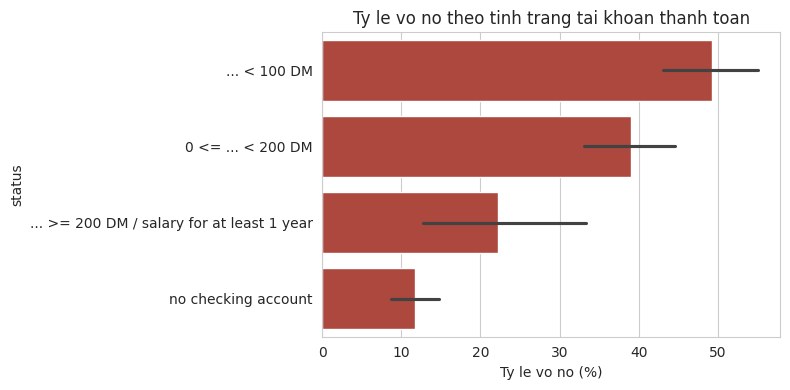

In [6]:
fig, ax = plt.subplots(figsize=(8,4))
order = df.groupby('status')['default'].mean().sort_values(ascending=False).index
sns.barplot(data=df, y='status', x='default', order=order, estimator=lambda x: sum(x)/len(x)*100, ax=ax, color='#c0392b')
ax.set_xlabel('Ty le vo no (%)')
ax.set_title('Ty le vo no theo tinh trang tai khoan thanh toan')
plt.tight_layout()
plt.show()


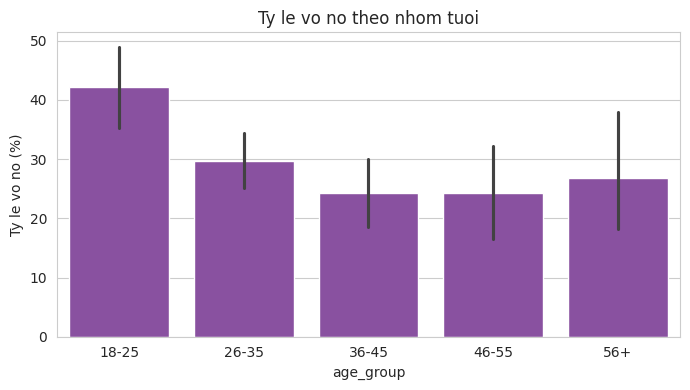

In [7]:
fig, ax = plt.subplots(figsize=(7,4))
order = ['18-25','26-35','36-45','46-55','56+']
sns.barplot(data=df, x='age_group', y='default', order=order, estimator=lambda x: sum(x)/len(x)*100, ax=ax, color='#8e44ad')
ax.set_ylabel('Ty le vo no (%)')
ax.set_title('Ty le vo no theo nhom tuoi')
plt.tight_layout()
plt.show()


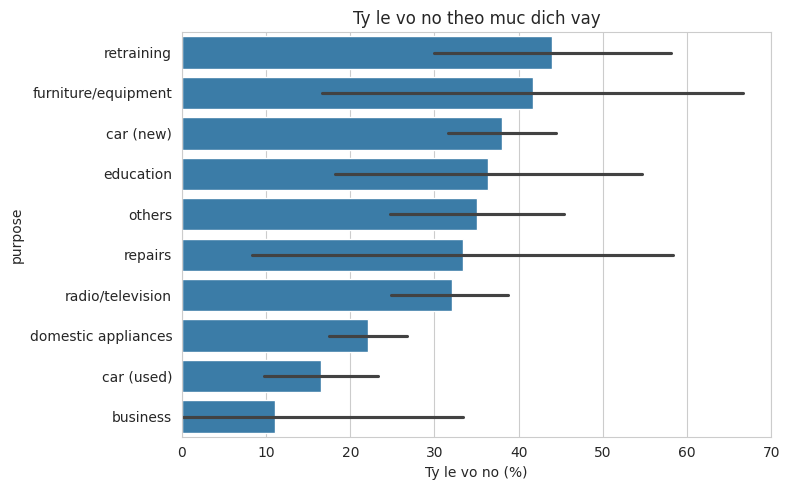

In [8]:
fig, ax = plt.subplots(figsize=(8,5))
order = df.groupby('purpose')['default'].mean().sort_values(ascending=False).index
sns.barplot(data=df, y='purpose', x='default', order=order, estimator=lambda x: sum(x)/len(x)*100, ax=ax, color='#2980b9')
ax.set_xlabel('Ty le vo no (%)')
ax.set_title('Ty le vo no theo muc dich vay')
plt.tight_layout()
plt.show()


**Insight chính:**
- Khách hàng có số dư tài khoản thanh toán thấp (`< 100 DM`) có tỷ lệ vỡ nợ cao nhất.
- Nhóm tuổi 18-25 rủi ro cao hơn hẳn các nhóm tuổi khác.
- Vay để đào tạo lại, mua nội thất, ô tô mới có rủi ro cao hơn vay kinh doanh hoặc mua ô tô cũ.


## 4. Xây dựng mô hình dự đoán (Logistic Regression)

In [9]:
model_df = df.drop(columns=['credit_risk', 'age_group', 'amount_group', 'personal_status_sex'])
cat_cols = model_df.select_dtypes(include='object').columns.tolist()

model_encoded = model_df.copy()
for c in cat_cols:
    le = LabelEncoder()
    model_encoded[c] = le.fit_transform(model_encoded[c])

X = model_encoded.drop(columns=['default'])
y = model_encoded['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_s, y_train)


/tmp/ipykernel_726/2653950093.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = model_df.select_dtypes(include='object').columns.tolist()


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [10]:
y_pred = clf.predict(X_test_s)
y_prob = clf.predict_proba(X_test_s)[:, 1]

print(f"AUC: {roc_auc_score(y_test, y_prob):.3f}")
print(classification_report(y_test, y_pred))


AUC: 0.751
              precision    recall  f1-score   support

           0       0.86      0.68      0.76       175
           1       0.50      0.75      0.60        75

    accuracy                           0.70       250
   macro avg       0.68      0.71      0.68       250
weighted avg       0.75      0.70      0.71       250



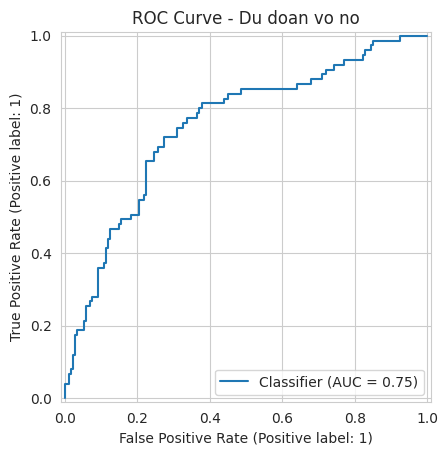

In [11]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('ROC Curve - Du doan vo no')
plt.show()


### Các yếu tố ảnh hưởng nhiều nhất đến rủi ro vỡ nợ

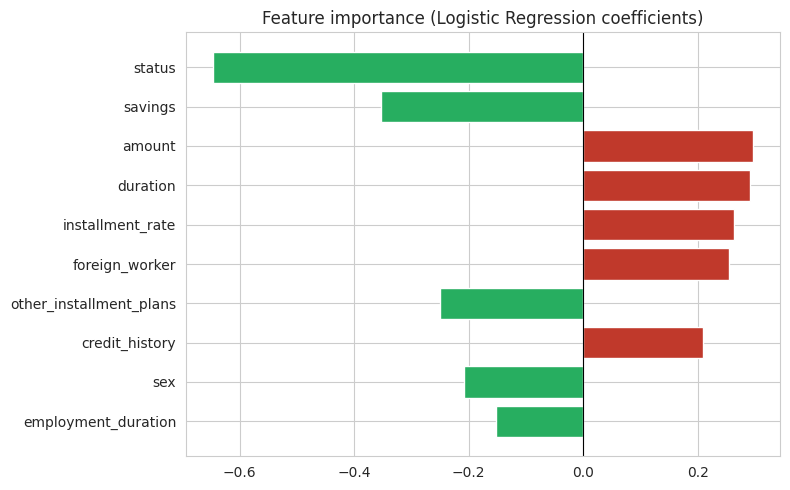

status                    -0.646604
savings                   -0.353073
amount                     0.296536
duration                   0.291427
installment_rate           0.263644
foreign_worker             0.255182
other_installment_plans   -0.250654
credit_history             0.209366
sex                       -0.207647
employment_duration       -0.152589
dtype: float64

In [12]:
coefs = pd.Series(clf.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
top10 = coefs.head(10)

fig, ax = plt.subplots(figsize=(8,5))
colors = ['#c0392b' if v>0 else '#27ae60' for v in top10.values]
ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature importance (Logistic Regression coefficients)')
plt.tight_layout()
plt.show()

top10


## 5. Kết luận & khuyến nghị

1. **Tình trạng tài khoản thanh toán** và **lịch sử tiết kiệm** là 2 tín hiệu rủi ro mạnh nhất — nên đưa vào bộ tiêu chí sàng lọc ưu tiên.
2. **Khách hàng trẻ (18-25 tuổi)** cần thẩm định kỹ hơn, đặc biệt với khoản vay kỳ hạn dài.
3. Mô hình Logistic Regression đạt AUC ~0.75 — đủ tốt để làm **công cụ hỗ trợ chấm điểm sơ bộ**, không thay thế thẩm định thủ công.
4. Hướng phát triển tiếp theo: thử nghiệm Random Forest/XGBoost, đánh giá fairness theo giới tính/quốc tịch trước khi triển khai thực tế.

*Xem báo cáo đầy đủ dạng Word: `Bao_cao_Phan_tich_Rui_ro_Tin_dung.docx`*
